In [7]:
import sys
import matplotlib.pyplot as plt
import pandas as pd
import math
from pathlib import Path
from hyperopt import fmin, tpe, hp, Trials
from scipy.integrate import solve_ivp

In [8]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
from model.fuelcell import PEMFC_1D
from model.coefficients import *
from configuration.initialize import *
from configuration.settings import *

In [9]:
# Initial conditions
current_density, Tfc = operating_inputs['current_density'], operating_inputs['Tfc']
Pa_des, Pc_des = operating_inputs['Pa_des'], operating_inputs['Pc_des']
Phi_a_des, Phi_c_des = operating_inputs['Phi_a_des'], operating_inputs['Phi_c_des']
Hmem, kappa_co, i0_c_ref, = parameters['Hmem'], parameters['kappa_co'], parameters['i0_c_ref']
kappa_c = parameters['kappa_c']
a_slim, b_slim, a_switch = parameters['a_slim'], parameters['b_slim'], parameters['a_switch']
n_gdl,n_mem = parameters['n_gdl'], parameters['n_mem']

# Mean value of the operating inputs
Phi_des_moy = (Phi_a_des + Phi_c_des) / 2
P_des_moy = (Pa_des + Pc_des) / 2

# Initial fuel cell states
#   Intermediate values
Psat_ini = 101325 * 10 ** (-2.1794 + 0.02953 * (Tfc - 273.15) - 9.1837e-5 * (Tfc - 273.15) ** 2 + 1.4454e-7 * (Tfc - 273.15) ** 3)
slim = a_slim * (Pc_des / 1e5) + b_slim
s_switch = a_switch * slim

def init_x(operating_inputs, parameters):
    C_v_ini =  Psat(343.13) / (R * 343.13)  #*Phi_des_moy # mol.m-3. It is the initial vapor concentration.
    C_H2_ini = (P_des_moy - Phi_des_moy * Psat_ini) / (R * Tfc)  # mol.m-3. It is the initial H2 concentration
    C_O2_ini = yO2_ext * (P_des_moy - Phi_des_moy * Psat_ini) / (R * Tfc)  # mol.m-3. It is the initial O2 concentration in the fuel cell.
    C_N2_ini = (1 - yO2_ext) * (P_des_moy - Phi_des_moy * Psat_ini) / (R * Tfc)  # mol.m-3. It is the initial N2  concentration in the fuel cell.
    s_ini = 0.001  # It is the initial liquid water saturation in the fuel cell.
    lambda_mem_ini = lambda_eq(C_v_ini, s_ini, Tfc, Kshape)  # It is the initial water content in the fuel cell.
    i_fc_ini = current_density(0)
    f_drop_ini = 0.5 * (1.0 - np.tanh((4 * s_ini - 2 * slim - 2 * s_switch) / (slim - s_switch)))
    # It is the initial cathode overpotential in the fuel cell.
    eta_c_ini = (1 / f_drop_ini * R * Tfc / (alpha_c * F) * np.log((i_fc_ini) / i0_c_ref * (C_O2ref / C_O2_ini) ** kappa_c) *
                        np.exp(Eact / R * (1 / 353 - 1 / Tfc)))

    # Initial auxiliary system state
    Pasm_ini, Paem_ini = Pa_des, P_des_moy  # Pa. It is the supply/exhaust manifold pressure at the anode side.
    Pcsm_ini, Pcem_ini = Pc_des, P_des_moy  # Pa. It is the supply/exhaust manifold pressure at the cathode side.
    Phi_asm_ini, Phi_aem_ini = Phi_a_des, Phi_des_moy  # It is the supply/exhaust manifold relative humidity
    #     at the anode side.
    Phi_csm_ini, Phi_cem_ini = Phi_c_des, Phi_des_moy  # It is the supply/exhaust manifold relative humidity
    #     at the cathode side.
    Wcp_ini = 0  # kg.s-1. It is the flow rate of the air compressor.
    Wa_inj_ini = 0  # kg.s-1. It is the flow rate of the air compressor at the anode side.
    Wc_inj_ini = 0  # kg.s-1. It is the flow rate of the air compressor at the cathode side.
    Abp_a_ini = 0  # It is the throttle area of the back pressure valve at the anode.
    Abp_c_ini = 0  # It is the throttle area of the back pressure valve at the cathode.

    # Main variable initialization
    C_v_agc, C_v_agdl, C_v_acl, C_v_ccl, C_v_cgdl, C_v_cgc = [C_v_ini/5] * 6
    s_agdl_init = [0.0] * (n_gdl-1)
    s_cgdl_init = [0.01 - 0.01 * i / (n_gdl-1) for i in range(n_gdl-1)]
    s_acl_init = 0.0
    s_ccl_init = 0.01
    s_boundary = 0  # Dirichlet boundary con
    s_boundary = 0  # Dirichlet boundary condition
    C_Pt2_ccl = 0
    C_Pt_mem_init = [0] * (n_mem - 1) + [C_Pt2_ccl/2]
    C_H2_mem_init = [0] + [0] * (n_mem -1)
    C_O2_mem_init = [0] * (n_mem - 1) + [0]
    C_H2_agc, C_H2_agdl, C_H2_acl = C_H2_ini, C_H2_ini, C_H2_ini
    C_O2_ccl, C_O2_cgdl, C_O2_cgc = C_O2_ini, C_O2_ini, C_O2_ini
    C_N2, eta_c = C_N2_ini, eta_c_ini
    Pasm, Paem, Pcsm, Pcem = Pasm_ini, Paem_ini, Pcsm_ini, Pcem_ini
    Phi_asm, Phi_aem, Phi_csm, Phi_cem = Phi_asm_ini, Phi_aem_ini, Phi_csm_ini, Phi_cem_ini
    Wcp, Wa_inj, Wc_inj, Abp_a, Abp_c = Wcp_ini, Wa_inj_ini, Wc_inj_ini, Abp_a_ini, Abp_c_ini
    prd_init = initPRD(resolution=computing_parameters['n_group_pt'])
    theta_CCL = np.zeros(computing_parameters['n_group_pt'])

    # Gathering of the variables initial value into one list
    return  ([C_H2_agc] + [C_H2_agdl] * n_gdl + [C_H2_acl] + C_H2_mem_init +
                    C_O2_mem_init + [C_O2_ccl] + [C_O2_cgdl] * n_gdl + [C_O2_cgc] + [C_N2] +
                    [C_v_agc] + [C_v_agdl] * n_gdl + [C_v_acl, C_v_ccl+1] + [C_v_cgdl] * n_gdl + [C_v_cgc] +
                    [0] + s_agdl_init + [0, s_ccl_init] + s_cgdl_init + [s_boundary] +
                    [2] + [lambda_mem_ini] * n_mem + [lambda_mem_ini] +
                    [eta_c, Pasm, Paem, Pcsm, Pcem, Phi_asm, Phi_aem, Phi_csm, Phi_cem] +
                    [Wcp, Wa_inj, Wc_inj, Abp_a, Abp_c] + C_Pt_mem_init +
                    [C_Pt2_ccl, Hmem] + prd_init.tolist() + theta_CCL.tolist() +
                    [operating_inputs["Tfc"]] * 32)

In [10]:
def generate_step_load(tstart, tend, i_low, i_high, tau_switch, t_switch):

    # --- Pre-computed constants (rebuild if any global above changes) ---
    _period  = tend - tstart
    _di      = i_high - i_low
    _t_rise  = float(tau_switch)               # rising-edge centre, in seconds from tstart
    _t_fall  = _period - float(tau_switch)     # falling-edge centre (symmetric within the period)
    _inv_w   = 6.0 / float(t_switch)           # 99.7 % of each transition completes within t_switch


    def current(t):
        """
        Periodic symmetric square-wave current density i(t) [A/m^2].

        Two C^infinity-smooth tanh transitions per period
        (tend - tstart):

            i(tau) = i_low + (i_high - i_low) * 0.5
                            * ( tanh((tau - tau_switch ) * 6 / t_switch)
                              - tanh((tau - (T - tau_switch)) * 6 / t_switch) )

        with T = tend - tstart. The rising edge is centred at
        ``tau_switch`` seconds into the period and the falling edge at
        ``T - tau_switch``, so the wave is symmetric around T/2:

          *   tau in [0, tau_switch - t_switch/2]            -> i = i_low
          *   tau in [tau_switch -+ t_switch/2]              -> smooth rise
          *   tau in [tau_switch + t_switch/2,
                      T - tau_switch - t_switch/2]           -> i = i_high
          *   tau in [T - tau_switch -+ t_switch/2]          -> smooth fall
          *   tau in [T - tau_switch + t_switch/2, T]        -> i = i_low

        and the boundary i(0) = i(T) = i_low is continuous (no jump at
        the period seam, unlike the legacy single-edge form).

        Typical 50/50 duty cycle for a 6 s period:
            tau_switch = 1.5   (so the transitions are at 1.5 s and 4.5 s)
            t_switch   = 0.5   (sharp but smooth transitions)

        Accepts scalar or array t.
        """
        tau = (t - tstart) % _period
        a   = (tau - _t_rise) * _inv_w
        b   = (tau - _t_fall) * _inv_w
        if isinstance(tau, np.ndarray):
            return i_low + _di * 0.5 * (np.tanh(a) - np.tanh(b))
        return i_low + _di * 0.5 * (math.tanh(a) - math.tanh(b))

    return current


In [11]:
# --- Global parameters ---
tstart     = 0.0      # start of each period                    [s]
tend       = 6.0    # end of each period                      [s]
i_low      = 0.002e4      # baseline current density                [A/m^2]
i_high     = 1.2e4    # plateau current density                 [A/m^2]
tau_switch = 1.0     # time (within a period) the ramp BEGINS  [s]
t_switch   = 3.0      # effective ramp duration                 [s]

step_load = generate_step_load(tstart, tend, i_low, i_high, tau_switch, t_switch)

In [13]:
operating_inputs["current_density"] = step_load
x_init = init_x(operating_inputs=operating_inputs, parameters=parameters)
model = PEMFC_1D(parameters==parameters, operating_inputs=operating_inputs, initial_variable_values=x_init)
solution_init = init_x(operating_inputs, parameters)
sol = solve_ivp(fun = model.dxdt, y0=solution_init, t_span=(0, 200), method='BDF', max_step=0.1)
model._recovery(sol)

TypeError: 'bool' object is not subscriptable

In [ ]:
states_simlog = model.variables
fluxes_simlog = model.fluxes
echem_traj_simlog = model.echem_traj

In [ ]:
t_start_plot = 50
i_start_plot = np.argmax(np.array(model.variables["t"]) > t_start_plot)
t_end_plot = 100
i_end_plot = np.argmin(np.array(model.variables["t"]) < t_end_plot)

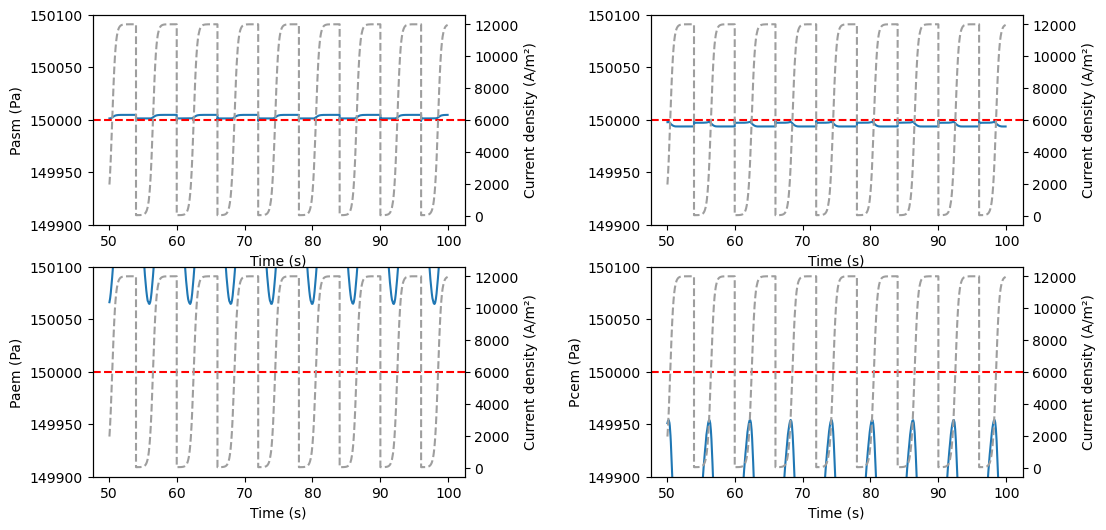

In [ ]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 6))
plt.subplots_adjust(wspace=0.5)
ax[0,0].plot(model.variables["t"][i_start_plot:i_end_plot], model.variables["Pasm"][i_start_plot:i_end_plot], label="Pasm")
ax[1,0].plot(model.variables["t"][i_start_plot:i_end_plot], model.variables["Pcsm"][i_start_plot:i_end_plot], label="Pcsm")
ax[0,0].set_ylabel("Pasm (Pa)")
ax[1,0].set_ylabel("Pcsm (Pa)")
ax[0,0].axhline(y=model.operating_inputs["Pa_des"], color='r', linestyle='--', label="Pa setpoint")
ax[0,1].axhline(y=model.operating_inputs["Pc_des"], color='r', linestyle='--', label="Pc setpoint")
ax[0,1].plot(model.variables["t"][i_start_plot:i_end_plot], model.variables["Paem"][i_start_plot:i_end_plot], label="Paem")
ax[1,1].plot(model.variables["t"][i_start_plot:i_end_plot], model.variables["Pcem"][i_start_plot:i_end_plot], label="Pcem")
ax[1,0].set_ylabel("Paem (Pa)")
ax[1,1].set_ylabel("Pcem (Pa)")
ax[1,0].axhline(y=model.operating_inputs["Pa_des"], color='r', linestyle='--', label="Pa setpoint")
ax[1,1].axhline(y=model.operating_inputs["Pc_des"], color='r', linestyle='--', label="Pc setpoint")

for ax_i in ax.flatten():
    ax_i.set_ylim(model.operating_inputs["Pa_des"] - 100, model.operating_inputs["Pa_des"] + 100)
    ax_load = ax_i.twinx()
    ax_load.plot(model.variables["t"][i_start_plot:i_end_plot], model.echem_traj["i_fc"][i_start_plot:i_end_plot], color = "#9E9E9E", linestyle='--', label="i_fc")
    ax_load.set_ylabel("Current density (A/m²)")
    ax_i.set_xlabel("Time (s)")

Kd two to three orders below Kp until you see the response.

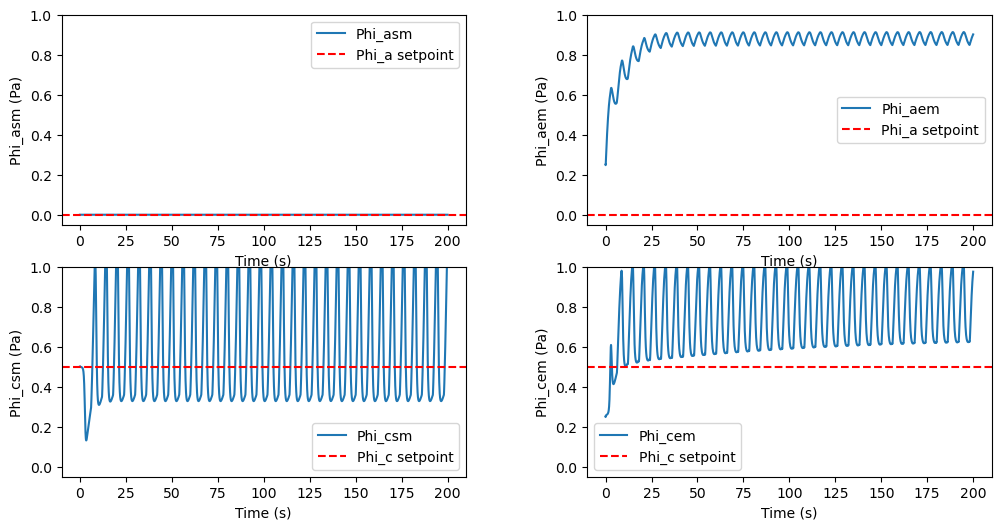

In [ ]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 6))
plt.subplots_adjust(wspace=0.3)
ax[0,0].plot(model.variables["t"], model.variables["Phi_asm"], label="Phi_asm")
ax[0,1].plot(model.variables["t"], model.variables["Phi_aem"], label="Phi_aem")
ax[1,1].plot(model.variables["t"], model.variables["Phi_cem"], label="Phi_cem")
ax[1,0].plot(model.variables["t"], model.variables["Phi_csm"], label="Phi_csm")
ax[0,0].set_ylabel("Phi_asm (Pa)")
ax[0,1].set_ylabel("Phi_aem (Pa)")
ax[1,0].set_ylabel("Phi_csm (Pa)")
ax[1,1].set_ylabel("Phi_cem (Pa)")
ax[0,0].axhline(y=model.operating_inputs["Phi_a_des"], color='r', linestyle='--', label="Phi_a setpoint")
ax[0,1].axhline(y=model.operating_inputs["Phi_a_des"], color='r', linestyle='--', label="Phi_a setpoint")
ax[1,0].axhline(y=model.operating_inputs["Phi_c_des"], color='r', linestyle='--', label="Phi_c setpoint")
ax[1,1].axhline(y=model.operating_inputs["Phi_c_des"], color='r', linestyle='--', label="Phi_c setpoint")
for axi in ax.flatten():
    axi.set_ylim(-0.05, 1)
    axi.legend()
    axi.set_xlabel("Time (s)")

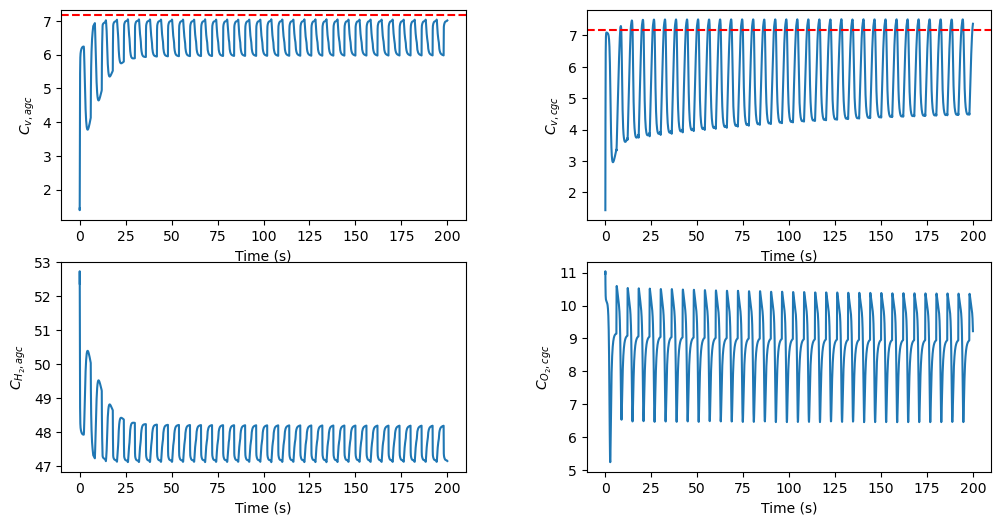

In [ ]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 6))
plt.subplots_adjust(wspace=0.3)
ax[0,0].plot(model.variables["t"], model.variables["C_v_agc"])
ax[0,0].axhline(y=C_v_sat(model.operating_inputs["Tfc"]), color='r', linestyle='--', label="Phi_a setpoint")
ax[0,1].plot(model.variables["t"], model.variables["C_v_cgc"])
ax[0,1].axhline(y=C_v_sat(model.operating_inputs["Tfc"]), color='r', linestyle='--', label="Phi_a setpoint")
ax[1,0].plot(model.variables["t"], model.variables["C_H2_agc"])
ax[1,1].plot(model.variables["t"], model.variables["C_O2_cgc"])
ax[0,0].set_ylabel(r"$C_{v,agc}$")
ax[0,1].set_ylabel(r"$C_{v,cgc}$")
ax[1,0].set_ylabel(r"$C_{H_2,agc}$")
ax[1,1].set_ylabel(r"$C_{O_2,cgc}$")
for axi in ax.flatten():
    axi.set_xlabel("Time (s)")

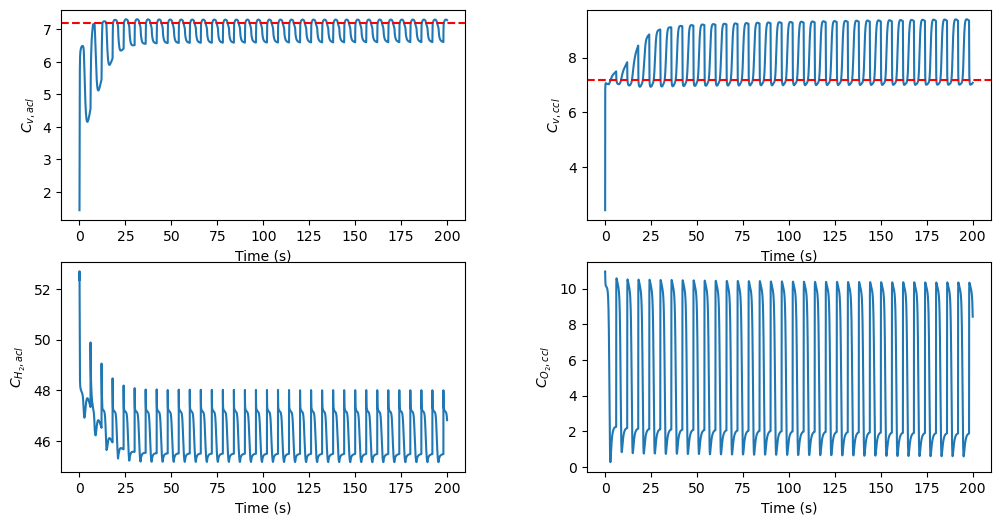

In [ ]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 6))
plt.subplots_adjust(wspace=0.3)
ax[0,0].plot(model.variables["t"], model.variables["C_v_acl"])
ax[0,0].axhline(y=C_v_sat(model.operating_inputs["Tfc"]), color='r', linestyle='--', label="Phi_a setpoint")
ax[0,1].plot(model.variables["t"], model.variables["C_v_ccl"])
ax[0,1].axhline(y=C_v_sat(model.operating_inputs["Tfc"]), color='r', linestyle='--', label="Phi_a setpoint")
ax[1,0].plot(model.variables["t"], model.variables["C_H2_acl"])
ax[1,1].plot(model.variables["t"], model.variables["C_O2_ccl"])
ax[0,0].set_ylabel(r"$C_{v,acl}$")
ax[0,1].set_ylabel(r"$C_{v,ccl}$")
ax[1,0].set_ylabel(r"$C_{H_2,acl}$")
ax[1,1].set_ylabel(r"$C_{O_2,ccl}$")
for axi in ax.flatten():
    axi.set_xlabel("Time (s)")

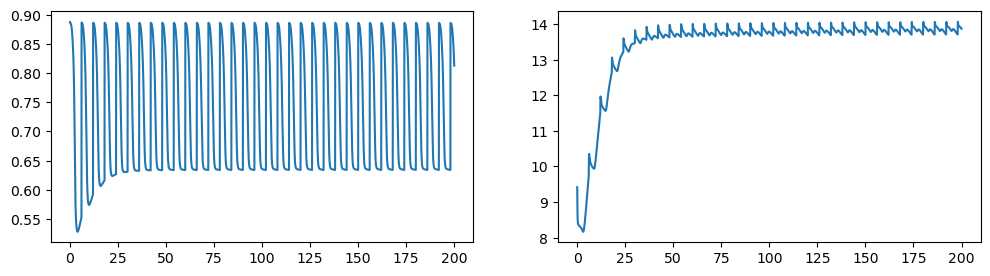

In [ ]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 3))
ax[0].plot(model.variables["t"], (np.array(model.echem_traj["Ucell"])-0.3))
ax[1].plot(model.variables["t"], model.variables["lambda_mem_5"])

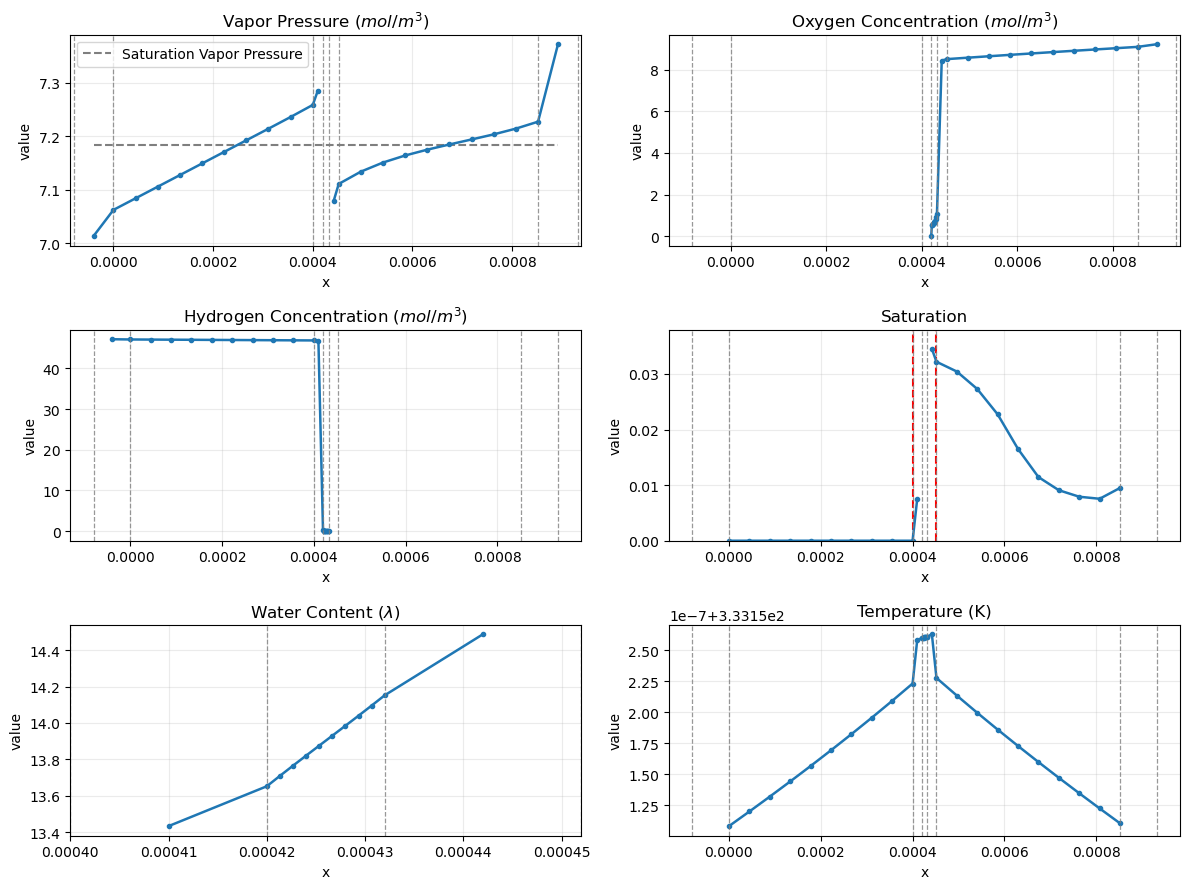

In [ ]:
from modules.display import display
display(sol, model)